# Modeling

# 1. Imports

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    mean_absolute_error, 
    root_mean_squared_error, 
    r2_score, 
    classification_report, 
    f1_score, 
    balanced_accuracy_score, 
    accuracy_score, 
    confusion_matrix,
    ConfusionMatrixDisplay
)
import joblib

# 2. Preprocessed Data Import

In [3]:
df_preprocessed = pd.read_csv(filepath_or_buffer='../data/preprocessed/dataset_preprocessed.csv')
df_preprocessed.head()

,tipo_de_entrada,tema_solicitud,sexo,alcaldia_solicitud,dia_solicitud,mes_solicitud,hora_sin,hora_cos,tiempo_resolución,tiempo_resolución_con_hora
0,Portal Ciudadano SUAC,FALTA DE AGUA,No especificado,Gustavo A. Madero,Wednesday,January,1.224647e-16,-1.000000,7.0,6.468537
1,Portal Ciudadano SUAC,FALTA DE AGUA,No especificado,Gustavo A. Madero,Wednesday,January,-5.000000e-01,-0.866025,7.0,6.375353
2,Portal Ciudadano SUAC,FALTA DE AGUA,No especificado,Gustavo A. Madero,Wednesday,January,-8.660254e-01,-0.500000,7.0,6.305584
3,Portal Ciudadano SUAC,FALTA DE AGUA,No especificado,Gustavo A. Madero,Wednesday,January,-9.659258e-01,-0.258819,7.0,6.265206
4,Portal Ciudadano SUAC,SOLICITUD DE VIGILANCIA POLICIACA,No especificado,Gustavo A. Madero,Wednesday,January,-9.659258e-01,0.258819,7.0,6.189034


# 3. Data Splitting

In [4]:
X = df_preprocessed.drop(columns=['tiempo_resolución_con_hora','tiempo_resolución'])
y = df_preprocessed['tiempo_resolución_con_hora']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Encoding

## 4.1 Encoding "Tema"

### 4.1.1 Obtain 80% of topics

In [6]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 1437328 entries, 896392 to 121958
Data columns (total 8 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   tipo_de_entrada     1437328 non-null  str    
 1   tema_solicitud      1437328 non-null  str    
 2   sexo                1437328 non-null  str    
 3   alcaldia_solicitud  1437328 non-null  str    
 4   dia_solicitud       1437328 non-null  str    
 5   mes_solicitud       1437328 non-null  str    
 6   hora_sin            1437328 non-null  float64
 7   hora_cos            1437328 non-null  float64
dtypes: float64(2), str(6)
memory usage: 207.2 MB


In [7]:
topic_counts = X_train['tema_solicitud'].value_counts(normalize=True)
topic_counts

tema_solicitud
OTRO                                               0.163581
FALTA DE AGUA                                      0.115147
REPARACIÓN Y MANTENIMIENTO DE ALUMBRADO PÚBLICO    0.109087
PODA                                               0.086972
FUGA DE AGUA                                       0.071737
                                                     ...   
RETIRO ÁRBOL                                       0.000017
COMEDORES COMUNITARIOS / PÚBLICOS                  0.000017
RECICLAJE                                          0.000013
INFORMACIÓN, PROGRAMAS Y EVENTOS PARA JÓVENES      0.000012
JORNADAS NOTARIALES                                0.000009
Name: proportion, Length: 72, dtype: float64

In [8]:
cumulative_frequency = topic_counts.drop(labels='OTRO').cumsum()
cumulative_frequency

tema_solicitud
FALTA DE AGUA                                      0.115147
REPARACIÓN Y MANTENIMIENTO DE ALUMBRADO PÚBLICO    0.224234
PODA                                               0.311207
FUGA DE AGUA                                       0.382944
BACHEO                                             0.444266
                                                     ...   
RETIRO ÁRBOL                                       0.836368
COMEDORES COMUNITARIOS / PÚBLICOS                  0.836385
RECICLAJE                                          0.836398
INFORMACIÓN, PROGRAMAS Y EVENTOS PARA JÓVENES      0.836410
JORNADAS NOTARIALES                                0.836419
Name: proportion, Length: 71, dtype: float64

In [9]:
top_categories = cumulative_frequency.where(cumulative_frequency <= 0.8).dropna().index.to_list()
top_categories

['FALTA DE AGUA',
 'REPARACIÓN Y MANTENIMIENTO DE ALUMBRADO PÚBLICO',
 'PODA',
 'FUGA DE AGUA',
 'BACHEO',
 'DESAZOLVE',
 'MANTENIMIENTO VÍA PÚBLICA',
 'SOLICITUD DE VIGILANCIA POLICIACA',
 'VERIFICACIÓN ADMINISTRATIVA',
 'RETIRO CASCAJO, ESCOMBRO, AZOLVE, RAMAS',
 'VEHÍCULO ABANDONADO / CHATARRIZACIÓN',
 'MANTENIMIENTO DE COLADERA / ALCANTARILLA',
 'QUEJA DE TRANSPORTE PÚBLICO',
 'BARBECHO / CHAPONEO',
 'MANTENIMIENTO DRENAJE',
 'RECOLECCIÓN BASURA',
 'LIMPIEZA VÍA PÚBLICA',
 'MANTENIMIENTO PARQUE / ÁREA VERDE',
 'PAVIMENTACIÓN / REENCARPETADO',
 'QUEJA SERVIDOR PÚBLICO',
 'MANTENIMIENTO DE BANQUETAS',
 'RETIRO AMBULANTE',
 'MANTENIMIENTO SEMÁFOROS',
 'PROTECCIÓN CIVIL',
 'RECUPERACIÓN DE VIALIDADES',
 'USO DE SUELO',
 'TRÁMITES / INFO MOVILIDAD']

### 4.1.2 Create Compact Topic Column

In [10]:
X_train['tema_solicitud_compact'] = X_train['tema_solicitud'].where(X_train['tema_solicitud'].isin(top_categories),other='OTRO')
print(X_train['tema_solicitud_compact'].value_counts(normalize=True).cumsum())

tema_solicitud_compact
OTRO                                               0.200178
FALTA DE AGUA                                      0.315325
REPARACIÓN Y MANTENIMIENTO DE ALUMBRADO PÚBLICO    0.424413
PODA                                               0.511385
FUGA DE AGUA                                       0.583122
BACHEO                                             0.644444
DESAZOLVE                                          0.701649
MANTENIMIENTO VÍA PÚBLICA                          0.739283
SOLICITUD DE VIGILANCIA POLICIACA                  0.765850
VERIFICACIÓN ADMINISTRATIVA                        0.791992
RETIRO CASCAJO, ESCOMBRO, AZOLVE, RAMAS            0.817103
VEHÍCULO ABANDONADO / CHATARRIZACIÓN               0.841543
MANTENIMIENTO DE COLADERA / ALCANTARILLA           0.865900
QUEJA DE TRANSPORTE PÚBLICO                        0.883015
BARBECHO / CHAPONEO                                0.898822
MANTENIMIENTO DRENAJE                              0.913071
RECOLECCIÓN BASUR

In [11]:
X_test['tema_solicitud_compact'] = X_test['tema_solicitud'].where(X_test['tema_solicitud'].isin(top_categories),other='OTRO')

### 4.1.3 Drop Column

In [12]:
X_train.drop(columns=['tema_solicitud'],inplace=True)
X_train

,tipo_de_entrada,sexo,alcaldia_solicitud,dia_solicitud,mes_solicitud,hora_sin,hora_cos,tema_solicitud_compact
896392,Operador Telefónico LOCATEL,Masculino,Milpa Alta,Thursday,February,-2.588190e-01,9.659258e-01,OTRO
698494,Interoperabilidad Miguel Hidalgo,Masculino,Miguel Hidalgo,Friday,October,5.000000e-01,-8.660254e-01,OTRO
530910,App CDMX,No especificado,Cuauhtémoc,Friday,June,-1.000000e+00,-1.836970e-16,SOLICITUD DE VIGILANCIA POLICIACA
917091,Portal Ciudadano SUAC,Femenino,Cuauhtémoc,Thursday,March,-7.071068e-01,-7.071068e-01,VERIFICACIÓN ADMINISTRATIVA
222355,App CDMX,No especificado,Gustavo A. Madero,Sunday,May,1.224647e-16,-1.000000e+00,PODA
...,...,...,...,...,...,...,...,...
259178,Portal Ciudadano SUAC,No especificado,Iztacalco,Monday,June,-2.588190e-01,-9.659258e-01,PODA
1414414,Operador Telefónico LOCATEL,Masculino,Álvaro Obregón,Thursday,September,-1.000000e+00,-1.836970e-16,MANTENIMIENTO DE BANQUETAS
131932,Usuarios SUAC Dependencia,Masculino,Coyoacán,Wednesday,March,5.000000e-01,-8.660254e-01,FUGA DE AGUA
671155,Portal Ciudadano SUAC,Femenino,Benito Juárez,Tuesday,October,7.071068e-01,-7.071068e-01,FUGA DE AGUA


In [13]:
X_test.drop(columns=['tema_solicitud'],inplace=True)
X_test

,tipo_de_entrada,sexo,alcaldia_solicitud,dia_solicitud,mes_solicitud,hora_sin,hora_cos,tema_solicitud_compact
1127386,Interoperabilidad SACMEX,No especificado,Tlalpan,Wednesday,April,1.224647e-16,-1.000000e+00,MANTENIMIENTO DE COLADERA / ALCANTARILLA
408401,Usuarios SUAC Dependencia,No especificado,Coyoacán,Wednesday,October,2.588190e-01,-9.659258e-01,FUGA DE AGUA
1148573,Interoperabilidad SACMEX,No especificado,Azcapotzalco,Tuesday,May,2.588190e-01,-9.659258e-01,FUGA DE AGUA
1315448,App CDMX,No especificado,Venustiano Carranza,Monday,July,9.659258e-01,-2.588190e-01,MANTENIMIENTO SEMÁFOROS
1740493,Interoperabilidad SACMEX,No especificado,Venustiano Carranza,Friday,March,-5.000000e-01,-8.660254e-01,FALTA DE AGUA
...,...,...,...,...,...,...,...,...
338949,App CDMX,No especificado,Xochimilco,Saturday,August,-8.660254e-01,5.000000e-01,REPARACIÓN Y MANTENIMIENTO DE ALUMBRADO PÚBLICO
178981,Portal Ciudadano SUAC,Masculino,Gustavo A. Madero,Tuesday,April,-1.000000e+00,-1.836970e-16,MANTENIMIENTO VÍA PÚBLICA
1087486,Usuarios SUAC Dependencia,Masculino,Azcapotzalco,Tuesday,April,5.000000e-01,-8.660254e-01,PODA
571613,Operador Telefónico LOCATEL,Masculino,Miguel Hidalgo,Friday,July,7.071068e-01,-7.071068e-01,"RETIRO CASCAJO, ESCOMBRO, AZOLVE, RAMAS"


### 4.1.4 Keep Unexpanded Copies for Ordinal Branch

In [14]:
X_train_ord = X_train.copy()
X_test_ord = X_test.copy()

## 4.2 One-Hot Encoding (Branch A)

In [15]:
categorical_columns = ['tipo_de_entrada','sexo','alcaldia_solicitud','dia_solicitud','mes_solicitud','tema_solicitud_compact']
ohe = OneHotEncoder(sparse_output=False,handle_unknown='ignore')
for param in categorical_columns:
    param_encoded = ohe.fit_transform(X_train[[param]])
    param_columns = ohe.get_feature_names_out([param])
    X_train[param_columns] = param_encoded
    X_train.drop(columns=[param],inplace=True)
    param_encoded_test = ohe.transform(X_test[[param]])
    X_test[param_columns] = param_encoded_test
    X_test.drop(columns=[param],inplace=True)
X_train

,hora_sin,hora_cos,tipo_de_entrada_App CDMX,tipo_de_entrada_Interoperabilidad Iztapalapa,tipo_de_entrada_Interoperabilidad Miguel Hidalgo,tipo_de_entrada_Interoperabilidad SACMEX,tipo_de_entrada_Interoperabilidad Xochimilco,tipo_de_entrada_Operador Telefónico - Ventanilla,tipo_de_entrada_Operador Telefónico LOCATEL,tipo_de_entrada_Portal Ciudadano SUAC,...,tema_solicitud_compact_RECOLECCIÓN BASURA,tema_solicitud_compact_RECUPERACIÓN DE VIALIDADES,tema_solicitud_compact_REPARACIÓN Y MANTENIMIENTO DE ALUMBRADO PÚBLICO,tema_solicitud_compact_RETIRO AMBULANTE,"tema_solicitud_compact_RETIRO CASCAJO, ESCOMBRO, AZOLVE, RAMAS",tema_solicitud_compact_SOLICITUD DE VIGILANCIA POLICIACA,tema_solicitud_compact_TRÁMITES / INFO MOVILIDAD,tema_solicitud_compact_USO DE SUELO,tema_solicitud_compact_VEHÍCULO ABANDONADO / CHATARRIZACIÓN,tema_solicitud_compact_VERIFICACIÓN ADMINISTRATIVA
896392,-2.588190e-01,9.659258e-01,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
698494,5.000000e-01,-8.660254e-01,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
530910,-1.000000e+00,-1.836970e-16,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
917091,-7.071068e-01,-7.071068e-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
222355,1.224647e-16,-1.000000e+00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259178,-2.588190e-01,-9.659258e-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1414414,-1.000000e+00,-1.836970e-16,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
131932,5.000000e-01,-8.660254e-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
671155,7.071068e-01,-7.071068e-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 1437328 entries, 896392 to 121958
Data columns (total 78 columns):
 #   Column                                                                  Non-Null Count    Dtype  
---  ------                                                                  --------------    -----  
 0   hora_sin                                                                1437328 non-null  float64
 1   hora_cos                                                                1437328 non-null  float64
 2   tipo_de_entrada_App CDMX                                                1437328 non-null  float64
 3   tipo_de_entrada_Interoperabilidad Iztapalapa                            1437328 non-null  float64
 4   tipo_de_entrada_Interoperabilidad Miguel Hidalgo                        1437328 non-null  float64
 5   tipo_de_entrada_Interoperabilidad SACMEX                                1437328 non-null  float64
 6   tipo_de_entrada_Interoperabilidad Xochimilco                          

## 4.3 Ordinal Encoding (Branch B)

In [17]:
categorical_columns = ['tipo_de_entrada','sexo','alcaldia_solicitud','dia_solicitud','mes_solicitud','tema_solicitud_compact']
ord_e = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_ord_encoded = ord_e.fit_transform(X_train_ord[categorical_columns])
X_train_ord[categorical_columns] = X_train_ord_encoded
X_test_ord_encoded = ord_e.transform(X_test_ord[categorical_columns])
X_test_ord[categorical_columns] = X_test_ord_encoded

In [18]:
X_test_ord.head()

,tipo_de_entrada,sexo,alcaldia_solicitud,dia_solicitud,mes_solicitud,hora_sin,hora_cos,tema_solicitud_compact
1127386,3.0,2.0,11.0,6.0,0.0,1.224647e-16,-1.000000,7.0
408401,8.0,2.0,2.0,6.0,10.0,2.588190e-01,-0.965926,4.0
1148573,3.0,2.0,0.0,5.0,8.0,2.588190e-01,-0.965926,4.0
1315448,0.0,2.0,13.0,1.0,5.0,9.659258e-01,-0.258819,10.0
1740493,3.0,2.0,13.0,0.0,7.0,-5.000000e-01,-0.866025,3.0


In [19]:
len(ord_e.categories_)

6

# 5. Transformations

## 5.1 X Scaling

In [20]:
sc = StandardScaler()
train_hora_sc = sc.fit_transform(X_train[['hora_sin','hora_cos']])
X_train[['hora_sin','hora_cos']] = train_hora_sc
test_hora_sc = sc.transform(X_test[['hora_sin','hora_cos']])
X_test[['hora_sin','hora_cos']] = test_hora_sc

## 5.2 Y Transform

In [21]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# 6. Feature Importance Validation (Random Forest)

In [22]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 1437328 entries, 896392 to 121958
Data columns (total 78 columns):
 #   Column                                                                  Non-Null Count    Dtype  
---  ------                                                                  --------------    -----  
 0   hora_sin                                                                1437328 non-null  float64
 1   hora_cos                                                                1437328 non-null  float64
 2   tipo_de_entrada_App CDMX                                                1437328 non-null  float64
 3   tipo_de_entrada_Interoperabilidad Iztapalapa                            1437328 non-null  float64
 4   tipo_de_entrada_Interoperabilidad Miguel Hidalgo                        1437328 non-null  float64
 5   tipo_de_entrada_Interoperabilidad SACMEX                                1437328 non-null  float64
 6   tipo_de_entrada_Interoperabilidad Xochimilco                          

In [23]:
rf_raw_target = RandomForestRegressor(n_estimators=100, max_depth=15, max_features='sqrt', n_jobs=-1, random_state=0)
rf_raw_target.fit(X_train, y_train)
importances_raw = pd.Series(rf_raw_target.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importances_raw.head(20)

tema_solicitud_compact_BACHEO                               0.095797
tema_solicitud_compact_SOLICITUD DE VIGILANCIA POLICIACA    0.045671
alcaldia_solicitud_Coyoacán                                 0.040230
tema_solicitud_compact_MANTENIMIENTO VÍA PÚBLICA            0.039900
tema_solicitud_compact_PODA                                 0.038230
tema_solicitud_compact_FALTA DE AGUA                        0.033721
hora_sin                                                    0.032924
alcaldia_solicitud_Miguel Hidalgo                           0.032510
hora_cos                                                    0.031250
tipo_de_entrada_Usuarios SUAC Dependencia                   0.028136
tema_solicitud_compact_QUEJA DE TRANSPORTE PÚBLICO          0.025520
tipo_de_entrada_Portal Ciudadano SUAC                       0.024147
tipo_de_entrada_Interoperabilidad SACMEX                    0.023482
tema_solicitud_compact_OTRO                                 0.021869
alcaldia_solicitud_Tláhuac        

In [24]:
rf_log_target = RandomForestRegressor(n_estimators=100, max_depth=15, max_features='sqrt', n_jobs=-1, random_state=0)
rf_log_target.fit(X_train, y_train_log)
importances_log = pd.Series(rf_log_target.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importances_log.head(20)

tema_solicitud_compact_OTRO                                               0.073257
tema_solicitud_compact_BACHEO                                             0.066300
tema_solicitud_compact_SOLICITUD DE VIGILANCIA POLICIACA                  0.053620
tipo_de_entrada_Interoperabilidad SACMEX                                  0.053352
tipo_de_entrada_Interoperabilidad Iztapalapa                              0.045883
alcaldia_solicitud_Coyoacán                                               0.045202
alcaldia_solicitud_Tláhuac                                                0.038900
tema_solicitud_compact_FALTA DE AGUA                                      0.034462
tipo_de_entrada_Usuarios SUAC Dependencia                                 0.030840
alcaldia_solicitud_Gustavo A. Madero                                      0.024240
tema_solicitud_compact_QUEJA DE TRANSPORTE PÚBLICO                        0.024185
hora_cos                                                                  0.024082
hora

In [25]:
def original_feature(column_name):
    if column_name in ('hora_sin', 'hora_cos'):
        return 'hora_solicitud'
    else:
        for variable in categorical_columns:
            if column_name.startswith(variable):
                return variable
        return column_name

In [26]:
importances_log.index = importances_log.index.map(original_feature)

In [27]:
importances_log.groupby(importances_log.index).sum().sort_values(ascending=False)

tema_solicitud_compact    0.405389
alcaldia_solicitud        0.235109
tipo_de_entrada           0.200314
mes_solicitud             0.062975
hora_solicitud            0.046837
dia_solicitud             0.026654
sexo                      0.022722
dtype: float64

# 7. Linear Regression

## 7.1 All Features

In [28]:
X_train_1 = X_train.copy()
X_test_1 = X_test.copy()

In [29]:
lr_1 = LinearRegression(n_jobs=-1)
model_1 = lr_1.fit(X=X_train_1, y=y_train_log)
y_pred_1 = np.expm1(model_1.predict(X_test_1))
rmse_1 = root_mean_squared_error(y_true=y_test, y_pred=y_pred_1)
mae_1 = mean_absolute_error(y_true=y_test, y_pred=y_pred_1)
r2_1 = r2_score(y_true=y_test, y_pred=y_pred_1)
print(f'RMSE 1: {rmse_1}, MAE 1: {mae_1},  R2 1: {r2_1}')

RMSE 1: 72.92044604357882, MAE 1: 38.23415175264792,  R2 1: -0.07577519861333992


## 7.2 Without 'sexo' and 'dia'

In [30]:
columns_to_drop_v1 = []
for column in X_train.columns:
    if column.startswith('sexo'):
        columns_to_drop_v1.append(column)
    elif column.startswith('dia'):
        columns_to_drop_v1.append(column)
print(columns_to_drop_v1)

['sexo_Femenino', 'sexo_Masculino', 'sexo_No especificado', 'dia_solicitud_Friday', 'dia_solicitud_Monday', 'dia_solicitud_Saturday', 'dia_solicitud_Sunday', 'dia_solicitud_Thursday', 'dia_solicitud_Tuesday', 'dia_solicitud_Wednesday']


In [31]:
X_train_2 = X_train.drop(columns=columns_to_drop_v1)
X_test_2 = X_test.drop(columns=columns_to_drop_v1)

In [32]:
lr_2 = LinearRegression(n_jobs=-1)
model_2 = lr_2.fit(X=X_train_2, y=y_train_log)
y_pred_2 = np.expm1(model_2.predict(X_test_2))
rmse_2 = root_mean_squared_error(y_true=y_test, y_pred=y_pred_2)
mae_2 = mean_absolute_error(y_true=y_test, y_pred=y_pred_2)
r2_2 = r2_score(y_true=y_test, y_pred=y_pred_2)
print(f'RMSE 2: {rmse_2}, MAE 2: {mae_2}, R2 2: {r2_2}')

RMSE 2: 72.93251485947228, MAE 2: 38.2623095816697, R2 2: -0.07613132389597377


## 7.3 Without 'sexo', 'dia', 'mes' and 'hora'

In [33]:
columns_to_drop_v2 = []
for column in X_train.columns:
    if column.startswith('sexo'):
        columns_to_drop_v2.append(column)
    elif column.startswith('dia'):
        columns_to_drop_v2.append(column)
    elif column.startswith('mes'):
        columns_to_drop_v2.append(column)
    elif column.startswith('hora'):
        columns_to_drop_v2.append(column)
print(columns_to_drop_v2)

['hora_sin', 'hora_cos', 'sexo_Femenino', 'sexo_Masculino', 'sexo_No especificado', 'dia_solicitud_Friday', 'dia_solicitud_Monday', 'dia_solicitud_Saturday', 'dia_solicitud_Sunday', 'dia_solicitud_Thursday', 'dia_solicitud_Tuesday', 'dia_solicitud_Wednesday', 'mes_solicitud_April', 'mes_solicitud_August', 'mes_solicitud_December', 'mes_solicitud_February', 'mes_solicitud_January', 'mes_solicitud_July', 'mes_solicitud_June', 'mes_solicitud_March', 'mes_solicitud_May', 'mes_solicitud_November', 'mes_solicitud_October', 'mes_solicitud_September']


In [34]:
X_train_3 = X_train.drop(columns=columns_to_drop_v2)
X_test_3 = X_test.drop(columns=columns_to_drop_v2)

In [35]:
lr_3 = LinearRegression(n_jobs=-1)
model_3 = lr_3.fit(X=X_train_3, y=y_train_log)
y_pred_3 = np.expm1(model_3.predict(X_test_3))
rmse_3 = root_mean_squared_error(y_true=y_test, y_pred=y_pred_3)
mae_3 = mean_absolute_error(y_true=y_test, y_pred=y_pred_3)
r2_3 = r2_score(y_true=y_test, y_pred=y_pred_3)
print(f'RMSE 3: {rmse_3}, MAE 3: {mae_3}, R2 3: {r2_3}')

RMSE 3: 72.99185669570824, MAE 3: 38.306890956829356, R2 3: -0.07788323355461757


# 8. Random Forest Regressor

## 8.1 Model

In [36]:
columns_to_drop_final = []
for column in X_train.columns:
    if column.startswith('sexo'):
        columns_to_drop_final.append(column)
    elif column.startswith('dia'):
        columns_to_drop_final.append(column)
print(columns_to_drop_final)

['sexo_Femenino', 'sexo_Masculino', 'sexo_No especificado', 'dia_solicitud_Friday', 'dia_solicitud_Monday', 'dia_solicitud_Saturday', 'dia_solicitud_Sunday', 'dia_solicitud_Thursday', 'dia_solicitud_Tuesday', 'dia_solicitud_Wednesday']


In [37]:
X_train_final = X_train.drop(columns=columns_to_drop_final)
X_test_final = X_test.drop(columns=columns_to_drop_final)

In [38]:
param_dict = {
    'n_estimators' : [100, 200, 300, 500],
    'max_depth' : [10, 15, 20, 25],
    'min_samples_split' : [2, 5, 10, 20],
    'min_samples_leaf' : [1, 2, 5, 10]
}

In [ ]:
rfr = RandomForestRegressor(max_features='sqrt', n_jobs=-1, random_state=0)
random_search = RandomizedSearchCV(
    estimator=rfr,
    param_distributions=param_dict,
    n_iter=20,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=0,
    verbose=2
)

random_search.fit(X=X_train_final, y=y_train_log)

print(random_search.best_params_)
print(random_search.best_score_)

## 8.2 Results

In [ ]:
y_pred_rf = np.expm1(random_search.best_estimator_.predict(X_test_final))
rmse_rfr = root_mean_squared_error(y_true=y_test, y_pred=y_pred_rf)
mae_rfr = mean_absolute_error(y_true=y_test, y_pred=y_pred_rf)
r2_rfr = r2_score(y_true=y_test, y_pred=y_pred_rf)
print(f'RMSE RFR: {rmse_rfr}, MAE RFR: {mae_rfr}, R2 RFR: {r2_rfr}')

In [ ]:
joblib.dump(random_search, '../data/models/rfr_random_search.joblib', compress=3)

In [ ]:
import plotly.express as px

rf_residuals = y_test - y_pred_rf

fig = px.histogram(rf_residuals, nbins=100, title='Residuals Distribution — Random Forest')
fig.update_layout(xaxis_title='Residual (y_test - y_pred)', yaxis_title='Frequency')
fig.show()

# 9. Classification Reformulation

## 9.1 Categorical Target Creation

In [40]:
bins = [0, 1, 3, 7, 30, np.inf]
labels = ['Up to 1 day', '2 to 3 days', '4 to 7 days', '1 to 4 weeks', 'Over 1 month']
y_train_class = pd.cut(y_train, bins=bins, labels=labels)
y_test_class = pd.cut(y_test, bins=bins, labels=labels)

In [41]:
dist_y_train_norm = y_train_class.value_counts(normalize=True, sort=False)
dist_y_train_norm

tiempo_resolución_con_hora
Up to 1 day     0.042871
2 to 3 days     0.071558
4 to 7 days     0.135426
1 to 4 weeks    0.331451
Over 1 month    0.418694
Name: proportion, dtype: float64

In [42]:
dist_y_train_ab = y_train_class.value_counts(normalize=False, sort=False)
dist_y_train_ab

tiempo_resolución_con_hora
Up to 1 day      61619
2 to 3 days     102852
4 to 7 days     194652
1 to 4 weeks    476404
Over 1 month    601801
Name: count, dtype: int64

In [43]:
y_train_class.isna().sum()

np.int64(0)

In [44]:
dist_y_test_norm = y_test_class.value_counts(normalize=True, sort=False)
dist_y_test_norm

tiempo_resolución_con_hora
Up to 1 day     0.043227
2 to 3 days     0.071341
4 to 7 days     0.135220
1 to 4 weeks    0.330869
Over 1 month    0.419344
Name: proportion, dtype: float64

In [45]:
dist_y_test_ab = y_test_class.value_counts(normalize=False, sort=False)
dist_y_test_ab

tiempo_resolución_con_hora
Up to 1 day      15533
2 to 3 days      25635
4 to 7 days      48589
1 to 4 weeks    118892
Over 1 month    150684
Name: count, dtype: int64

In [46]:
y_test_class.isna().sum()

np.int64(0)

### 9.1.1 Class Distribution

In [47]:
df_class_dis = pd.concat([dist_y_train_norm,dist_y_train_ab], axis=1)
df_class_dis

,proportion,count
tiempo_resolución_con_hora,,
Up to 1 day,0.042871,61619
2 to 3 days,0.071558,102852
4 to 7 days,0.135426,194652
1 to 4 weeks,0.331451,476404
Over 1 month,0.418694,601801


In [48]:
df_class_dis = df_class_dis.reset_index()

In [ ]:
fig = px.bar(x=df_class_dis['tiempo_resolución_con_hora'], y=df_class_dis['proportion'])
fig.update_layout(xaxis_title='Category of Resolution Time', yaxis_title='Proportion')
fig.show()

## 9.2 Dummy Classifier

In [49]:
dc = DummyClassifier(strategy='most_frequent', random_state=0)
dummy_model = dc.fit(X_train_final, y_train_class)
y_pred_dummy = dummy_model.predict(X_test_final)

In [50]:
print(classification_report(y_test_class, y_pred_dummy, labels=labels))

/Users/sergiobenhumea/miniforge3/envs/ds_full/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sergiobenhumea/miniforge3/envs/ds_full/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

 Up to 1 day       0.00      0.00      0.00     15533
 2 to 3 days       0.00      0.00      0.00     25635
 4 to 7 days       0.00      0.00      0.00     48589
1 to 4 weeks       0.00      0.00      0.00    118892
Over 1 month       0.42      1.00      0.59    150684

    accuracy                           0.42    359333
   macro avg       0.08      0.20      0.12    359333
weighted avg       0.18      0.42      0.25    359333



/Users/sergiobenhumea/miniforge3/envs/ds_full/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [51]:
acc_dummy = accuracy_score(y_test_class, y_pred_dummy)
f1_dummy = f1_score(y_test_class, y_pred_dummy, average='macro')
balanced_dummy = balanced_accuracy_score(y_test_class, y_pred_dummy)
print(f'Classification Metrics: Accuracy - {acc_dummy}, F1-score - {f1_dummy}, Balanced Accuracy Score - {balanced_dummy}')

Classification Metrics: Accuracy - 0.41934361720187124, F1-score - 0.11817959009209497, Balanced Accuracy Score - 0.2


# 10. Explainable Models

In [52]:
X_train_ord.drop(columns=['sexo','dia_solicitud'], inplace=True)

In [53]:
X_test_ord.drop(columns=['sexo','dia_solicitud'], inplace=True)

## 10.1 Shallow Decision Tree

In [54]:
dtc_1 = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=0)
decision_tree_model_1 = dtc_1.fit(X_train_ord, y_train_class)

In [142]:
y_pred_shallow_tree = decision_tree_model_1.predict(X_test_ord)
print(classification_report(y_test_class, y_pred_shallow_tree, labels=labels))

/Users/sergiobenhumea/miniforge3/envs/ds_full/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sergiobenhumea/miniforge3/envs/ds_full/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

 Up to 1 day       0.12      0.49      0.19     15533
 2 to 3 days       0.00      0.00      0.00     25635
 4 to 7 days       0.22      0.17      0.19     48589
1 to 4 weeks       0.34      0.44      0.38    118892
Over 1 month       0.52      0.36      0.43    150684

    accuracy                           0.34    359333
   macro avg       0.24      0.29      0.24    359333
weighted avg       0.37      0.34      0.34    359333



/Users/sergiobenhumea/miniforge3/envs/ds_full/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [144]:
acc_shallow_dt = accuracy_score(y_test_class, y_pred_shallow_tree)
f1_shallow_dt = f1_score(y_test_class, y_pred_shallow_tree, average='macro')
balanced_shallow_dt = balanced_accuracy_score(y_test_class, y_pred_shallow_tree)
print(f'Classification Metrics: Accuracy - {acc_shallow_dt}, F1-score - {f1_shallow_dt}, Balanced Accuracy Score - {balanced_shallow_dt}')

Classification Metrics: Accuracy - 0.34017192965856186, F1-score - 0.23776004266391076, Balanced Accuracy Score - 0.29164202334384903


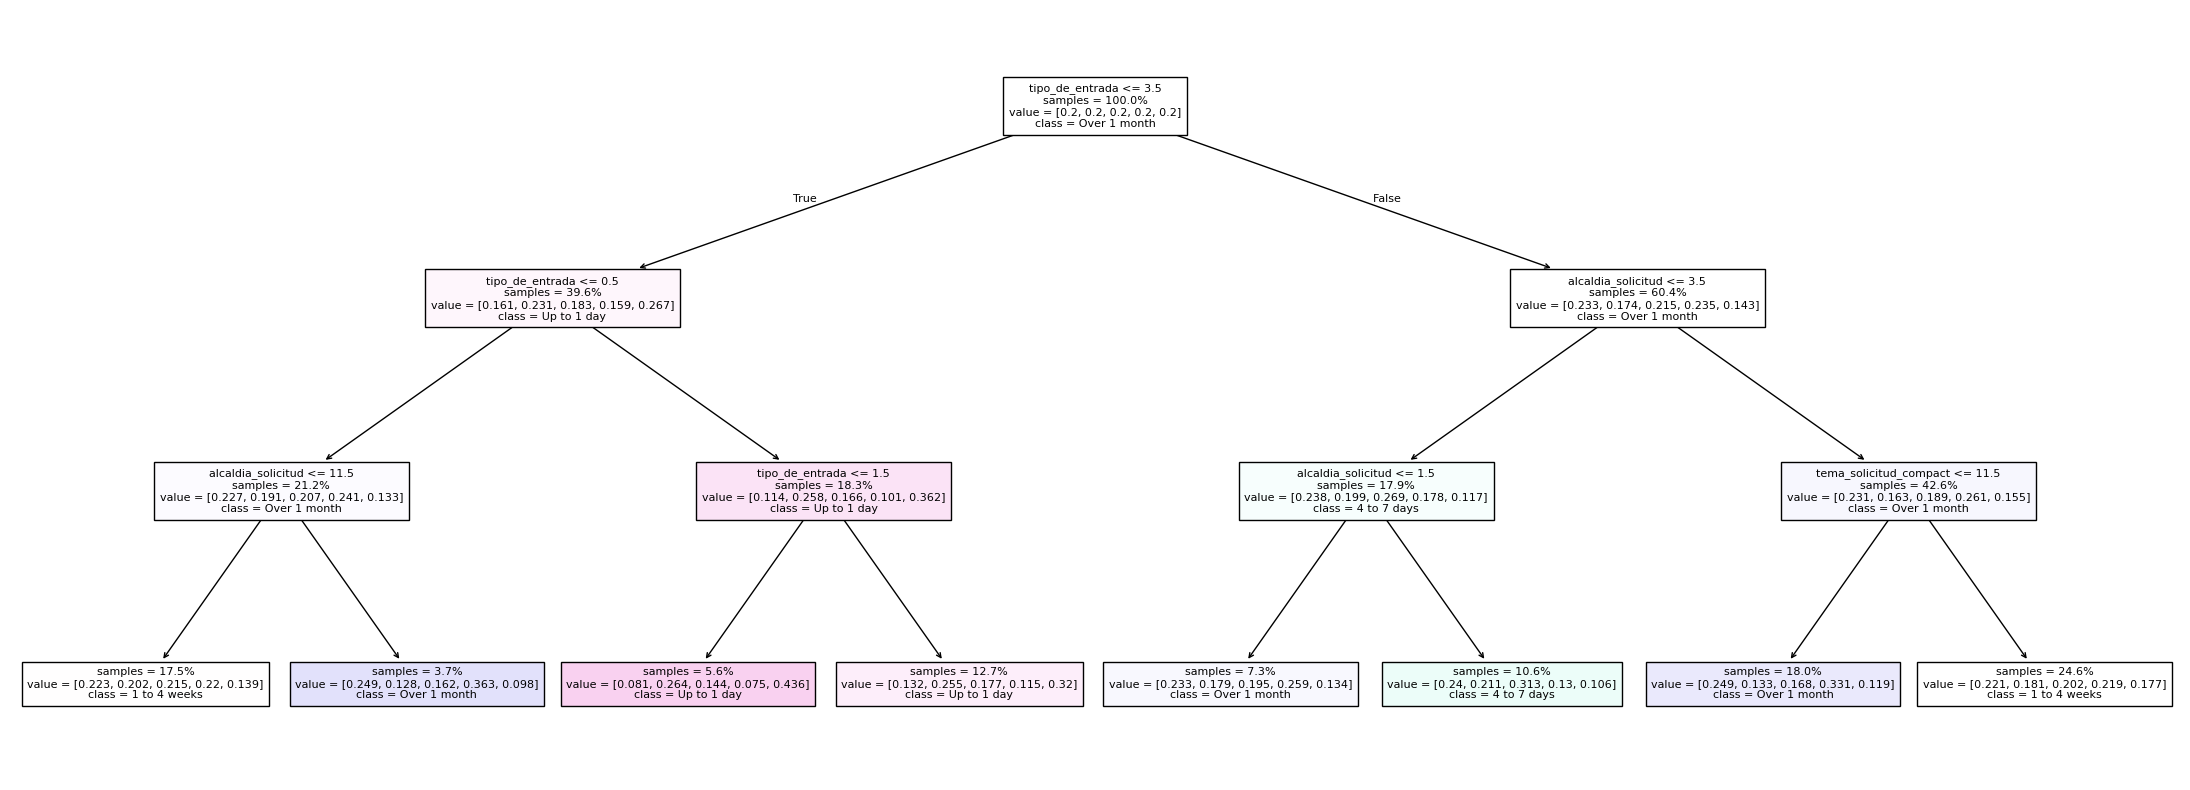

In [55]:
fig, ax = plt.subplots(figsize=(28,10))
plot_tree(
    decision_tree_model_1, 
    ax=ax, 
    feature_names=X_train_ord.columns.to_list(), 
    class_names=decision_tree_model_1.classes_, 
    filled=True,
    impurity=False,
    proportion=True,
    fontsize=8
)
plt.show()

## 10.2 Rule Extraction

### 10.2.1 By Entry Topic

In [ ]:
train_topics = df_preprocessed.loc[y_train.index, 'tema_solicitud']
category_rates_1 = pd.crosstab(train_topics, y_train_class, normalize='index')
category_rates_1 = category_rates_1.sort_values('Over 1 month', ascending=False)
category_rates_1.reset_index(inplace=True)

In [57]:
top_topics = train_topics.value_counts().head(15).reset_index()
top_topics

,tema_solicitud,count
0,OTRO,235120
1,FALTA DE AGUA,165504
2,REPARACIÓN Y MANTENIMIENTO DE ALUMBRADO PÚBLICO,156794
3,PODA,125008
4,FUGA DE AGUA,103110
5,BACHEO,88140
6,DESAZOLVE,82222
7,MANTENIMIENTO VÍA PÚBLICA,54092
8,SOLICITUD DE VIGILANCIA POLICIACA,38185
9,VERIFICACIÓN ADMINISTRATIVA,37575


In [ ]:
rates_1 = category_rates_1.merge(top_topics, on='tema_solicitud')
rates_1

,tema_solicitud,Up to 1 day,2 to 3 days,4 to 7 days,1 to 4 weeks,Over 1 month,count
0,BACHEO,0.016156,0.036771,0.082074,0.225278,0.639721,88140
1,MANTENIMIENTO VÍA PÚBLICA,0.022221,0.041818,0.085965,0.254807,0.595190,54092
2,MANTENIMIENTO DE COLADERA / ALCANTARILLA,0.022537,0.046331,0.099632,0.265246,0.566254,35009
3,DESAZOLVE,0.016078,0.036547,0.103196,0.325728,0.518450,82222
4,PODA,0.039485,0.065988,0.115265,0.268759,0.510503,125008
5,REPARACIÓN Y MANTENIMIENTO DE ALUMBRADO PÚBLICO,0.019031,0.040021,0.111267,0.325905,0.503776,156794
6,BARBECHO / CHAPONEO,0.032482,0.043310,0.100220,0.334463,0.489525,22720
7,VERIFICACIÓN ADMINISTRATIVA,0.031670,0.062063,0.121916,0.318270,0.466081,37575
8,VEHÍCULO ABANDONADO / CHATARRIZACIÓN,0.002790,0.020524,0.070255,0.452589,0.453842,35129
9,"RETIRO CASCAJO, ESCOMBRO, AZOLVE, RAMAS",0.020697,0.055689,0.139667,0.366470,0.417477,36093


### 10.2.2 By Municipality

In [59]:
train_municipalities = df_preprocessed.loc[y_train.index, 'alcaldia_solicitud']
category_rates_2 = pd.crosstab(train_municipalities, y_train_class, normalize='index')
category_rates_2 = category_rates_2.sort_values('Over 1 month', ascending=False)
category_rates_2.reset_index(inplace=True)

In [60]:
top_municipalities = train_municipalities.value_counts().head(15).reset_index()
top_municipalities

,alcaldia_solicitud,count
0,Coyoacán,179575
1,Iztapalapa,167239
2,Gustavo A. Madero,152516
3,Cuauhtémoc,127260
4,Tlalpan,111218
5,Xochimilco,105706
6,Miguel Hidalgo,103420
7,Álvaro Obregón,89175
8,Azcapotzalco,86039
9,Iztacalco,81437


In [61]:
rates_2 = category_rates_2.merge(top_municipalities, on='alcaldia_solicitud')
rates_2

,alcaldia_solicitud,Up to 1 day,2 to 3 days,4 to 7 days,1 to 4 weeks,Over 1 month,count
0,Tláhuac,0.012933,0.028072,0.060430,0.265849,0.632717,55287
1,Álvaro Obregón,0.039350,0.050227,0.084160,0.278015,0.548248,89175
2,Gustavo A. Madero,0.030961,0.049516,0.087374,0.320353,0.511795,152516
3,La Magdalena Contreras,0.051646,0.074500,0.121067,0.249839,0.502948,23235
4,Xochimilco,0.032401,0.055948,0.130125,0.319225,0.462301,105706
5,Venustiano Carranza,0.029024,0.046093,0.094249,0.369253,0.461382,35385
6,Cuauhtémoc,0.026780,0.062070,0.128021,0.329161,0.453968,127260
7,Azcapotzalco,0.024222,0.047943,0.103070,0.371204,0.453562,86039
8,Benito Juárez,0.039691,0.089171,0.151993,0.298110,0.421034,80497
9,Iztapalapa,0.107947,0.119075,0.136493,0.260860,0.375624,167239


### 10.2.3 By Input Medium

In [101]:
train_input = df_preprocessed.loc[y_train.index, 'tipo_de_entrada']
category_rates_3 = pd.crosstab(train_input, y_train_class, normalize='index')
category_rates_3 = category_rates_3.sort_values('Over 1 month', ascending=False)
category_rates_3.reset_index(inplace=True)

In [102]:
top_inputs = train_input.value_counts().head(15).reset_index()
top_inputs

,tipo_de_entrada,count
0,Portal Ciudadano SUAC,369301
1,App CDMX,305382
2,Usuarios SUAC Dependencia,201234
3,Operador Telefónico LOCATEL,193073
4,Interoperabilidad SACMEX,119296
5,Operador Telefónico - Ventanilla,83183
6,Interoperabilidad Iztapalapa,80203
7,Interoperabilidad Miguel Hidalgo,63910
8,Interoperabilidad Xochimilco,18689
9,Whatsapp,3057


In [103]:
rates_3 = category_rates_3.merge(top_inputs, on='tipo_de_entrada')
rates_3

,tipo_de_entrada,Up to 1 day,2 to 3 days,4 to 7 days,1 to 4 weeks,Over 1 month,count
0,Interoperabilidad Xochimilco,0.020386,0.016641,0.031623,0.209696,0.721654,18689
1,Operador Telefónico - Ventanilla,0.024007,0.037844,0.098890,0.344578,0.494680,83183
2,Operador Telefónico LOCATEL,0.023794,0.055730,0.132230,0.325343,0.462903,193073
3,App CDMX,0.025555,0.061117,0.125541,0.336749,0.451038,305382
4,Portal Ciudadano SUAC,0.028110,0.055020,0.123910,0.352536,0.440424,369301
5,Usuarios SUAC Dependencia,0.031799,0.067911,0.160783,0.368029,0.371478,201234
6,Whatsapp,0.035329,0.080471,0.170101,0.359503,0.354596,3057
7,Interoperabilidad Miguel Hidalgo,0.079362,0.115381,0.166703,0.295760,0.342795,63910
8,Interoperabilidad SACMEX,0.099769,0.127699,0.159997,0.295894,0.316641,119296
9,Interoperabilidad Iztapalapa,0.161852,0.163710,0.169458,0.232136,0.272845,80203


### 10.2.4 By Topic x Municipality

In [104]:
train_topic_municipality = df_preprocessed.loc[y_train.index, ['tema_solicitud','alcaldia_solicitud']]
category_rates_4 = pd.crosstab(index=[train_topic_municipality['tema_solicitud'],train_topic_municipality['alcaldia_solicitud']], columns=y_train_class, normalize='index')
category_rates_4 = category_rates_4.sort_values('Over 1 month', ascending=False)
category_rates_4.reset_index(inplace=True)

#### Combinations with over 2,000 entries

In [105]:
top_topic_municipality_over_2k = train_topic_municipality.value_counts()[train_topic_municipality.value_counts() >= 3000].reset_index()
top_topic_municipality_over_2k

,tema_solicitud,alcaldia_solicitud,count
0,OTRO,Iztapalapa,82674
1,OTRO,Miguel Hidalgo,60862
2,FALTA DE AGUA,Coyoacán,26428
3,PODA,Coyoacán,21688
4,REPARACIÓN Y MANTENIMIENTO DE ALUMBRADO PÚBLICO,Gustavo A. Madero,20884
...,...,...,...
119,VERIFICACIÓN ADMINISTRATIVA,Álvaro Obregón,3067
120,PODA,Venustiano Carranza,3061
121,BACHEO,Venustiano Carranza,3034
122,VERIFICACIÓN ADMINISTRATIVA,Coyoacán,3031


In [106]:
rates_4_over_2k = category_rates_4.merge(top_topic_municipality_over_2k, on=['tema_solicitud','alcaldia_solicitud'])
rates_4_over_2k

,tema_solicitud,alcaldia_solicitud,Up to 1 day,2 to 3 days,4 to 7 days,1 to 4 weeks,Over 1 month,count
0,REPARACIÓN Y MANTENIMIENTO DE ALUMBRADO PÚBLICO,Tláhuac,0.002615,0.001868,0.011956,0.050999,0.932561,5353
1,DESAZOLVE,Tláhuac,0.002910,0.004656,0.015131,0.142192,0.835112,5155
2,BACHEO,Xochimilco,0.002534,0.008237,0.028511,0.136220,0.824498,4735
3,BACHEO,Cuauhtémoc,0.008105,0.021658,0.041722,0.111214,0.817300,7526
4,DESAZOLVE,Álvaro Obregón,0.008194,0.006829,0.025676,0.148593,0.810707,3661
...,...,...,...,...,...,...,...,...
119,SOLICITUD DE VIGILANCIA POLICIACA,Coyoacán,0.014168,0.100979,0.199897,0.560793,0.124163,3882
120,FALTA DE AGUA,Coyoacán,0.040222,0.150598,0.303050,0.389700,0.116430,26428
121,LIMPIEZA VÍA PÚBLICA,Coyoacán,0.029635,0.124173,0.369581,0.379868,0.096743,4083
122,SOLICITUD DE VIGILANCIA POLICIACA,Iztapalapa,0.018953,0.115523,0.361613,0.412756,0.091155,3324


#### Combinations in the top 25 of entries

In [107]:
top_topic_municipality_top_25 = train_topic_municipality.value_counts().head(25).reset_index()
top_topic_municipality_top_25

,tema_solicitud,alcaldia_solicitud,count
0,OTRO,Iztapalapa,82674
1,OTRO,Miguel Hidalgo,60862
2,FALTA DE AGUA,Coyoacán,26428
3,PODA,Coyoacán,21688
4,REPARACIÓN Y MANTENIMIENTO DE ALUMBRADO PÚBLICO,Gustavo A. Madero,20884
5,FUGA DE AGUA,Gustavo A. Madero,20740
6,REPARACIÓN Y MANTENIMIENTO DE ALUMBRADO PÚBLICO,Coyoacán,19847
7,FUGA DE AGUA,Coyoacán,18270
8,FALTA DE AGUA,Tlalpan,17774
9,OTRO,Coyoacán,17321


In [108]:
rates_4_top_25 = category_rates_4.merge(top_topic_municipality_top_25, on=['tema_solicitud','alcaldia_solicitud'])
rates_4_top_25

,tema_solicitud,alcaldia_solicitud,Up to 1 day,2 to 3 days,4 to 7 days,1 to 4 weeks,Over 1 month,count
0,REPARACIÓN Y MANTENIMIENTO DE ALUMBRADO PÚBLICO,Cuauhtémoc,0.006921,0.027684,0.065968,0.156067,0.743360,16038
1,REPARACIÓN Y MANTENIMIENTO DE ALUMBRADO PÚBLICO,Iztapalapa,0.013786,0.019042,0.030501,0.231604,0.705066,11606
2,BACHEO,Gustavo A. Madero,0.012924,0.023430,0.052528,0.216613,0.694505,13231
3,REPARACIÓN Y MANTENIMIENTO DE ALUMBRADO PÚBLICO,Xochimilco,0.012441,0.031852,0.128682,0.236529,0.590497,13343
4,PODA,Coyoacán,0.016138,0.045924,0.154325,0.228606,0.555007,21688
5,DESAZOLVE,Gustavo A. Madero,0.007822,0.019842,0.065783,0.357731,0.548823,12146
6,REPARACIÓN Y MANTENIMIENTO DE ALUMBRADO PÚBLICO,Gustavo A. Madero,0.002777,0.010630,0.054061,0.393363,0.539169,20884
7,FUGA DE AGUA,Gustavo A. Madero,0.048216,0.046721,0.060125,0.308582,0.536355,20740
8,FALTA DE AGUA,Xochimilco,0.021962,0.060978,0.112692,0.328937,0.475431,16301
9,REPARACIÓN Y MANTENIMIENTO DE ALUMBRADO PÚBLICO,Tlalpan,0.015974,0.046393,0.081244,0.398884,0.457505,13084


In [112]:
rates_4_top_25.head(10)

,tema_solicitud,alcaldia_solicitud,Up to 1 day,2 to 3 days,4 to 7 days,1 to 4 weeks,Over 1 month,count
0,REPARACIÓN Y MANTENIMIENTO DE ALUMBRADO PÚBLICO,Cuauhtémoc,0.006921,0.027684,0.065968,0.156067,0.743360,16038
1,REPARACIÓN Y MANTENIMIENTO DE ALUMBRADO PÚBLICO,Iztapalapa,0.013786,0.019042,0.030501,0.231604,0.705066,11606
2,BACHEO,Gustavo A. Madero,0.012924,0.023430,0.052528,0.216613,0.694505,13231
3,REPARACIÓN Y MANTENIMIENTO DE ALUMBRADO PÚBLICO,Xochimilco,0.012441,0.031852,0.128682,0.236529,0.590497,13343
4,PODA,Coyoacán,0.016138,0.045924,0.154325,0.228606,0.555007,21688
5,DESAZOLVE,Gustavo A. Madero,0.007822,0.019842,0.065783,0.357731,0.548823,12146
6,REPARACIÓN Y MANTENIMIENTO DE ALUMBRADO PÚBLICO,Gustavo A. Madero,0.002777,0.010630,0.054061,0.393363,0.539169,20884
7,FUGA DE AGUA,Gustavo A. Madero,0.048216,0.046721,0.060125,0.308582,0.536355,20740
8,FALTA DE AGUA,Xochimilco,0.021962,0.060978,0.112692,0.328937,0.475431,16301
9,REPARACIÓN Y MANTENIMIENTO DE ALUMBRADO PÚBLICO,Tlalpan,0.015974,0.046393,0.081244,0.398884,0.457505,13084


In [113]:
rates_4_top_25.tail(10)

,tema_solicitud,alcaldia_solicitud,Up to 1 day,2 to 3 days,4 to 7 days,1 to 4 weeks,Over 1 month,count
15,OTRO,Miguel Hidalgo,0.081348,0.115129,0.167855,0.296556,0.339111,60862
16,OTRO,Cuauhtémoc,0.037623,0.069858,0.136936,0.444087,0.311495,11509
17,OTRO,Coyoacán,0.036776,0.074418,0.184343,0.430633,0.273829,17321
18,OTRO,Iztapalapa,0.159506,0.162917,0.170646,0.234862,0.272069,82674
19,FALTA DE AGUA,Gustavo A. Madero,0.108038,0.141571,0.152923,0.325939,0.271529,15328
20,PODA,Cuauhtémoc,0.039292,0.130419,0.245904,0.331521,0.252864,13794
21,REPARACIÓN Y MANTENIMIENTO DE ALUMBRADO PÚBLICO,Coyoacán,0.013403,0.045901,0.269512,0.419106,0.252078,19847
22,FALTA DE AGUA,Tlalpan,0.021323,0.060425,0.120851,0.566445,0.230955,17774
23,FUGA DE AGUA,Coyoacán,0.029830,0.076409,0.217132,0.535851,0.140777,18270
24,FALTA DE AGUA,Coyoacán,0.040222,0.150598,0.303050,0.389700,0.116430,26428


#### Verification

In [114]:
test_topic_municipality = df_preprocessed.loc[y_test.index, ['tema_solicitud','alcaldia_solicitud']]
category_rates_4_test = pd.crosstab(index=[test_topic_municipality['tema_solicitud'],test_topic_municipality['alcaldia_solicitud']], columns=y_test_class, normalize='index')
category_rates_4_test = category_rates_4_test.sort_values('Over 1 month', ascending=False)
category_rates_4_test.reset_index(inplace=True)

In [123]:
top_topic_municipality_top_25_test = top_topic_municipality_top_25[['tema_solicitud','alcaldia_solicitud']]
top_topic_municipality_top_25_test

,tema_solicitud,alcaldia_solicitud
0,OTRO,Iztapalapa
1,OTRO,Miguel Hidalgo
2,FALTA DE AGUA,Coyoacán
3,PODA,Coyoacán
4,REPARACIÓN Y MANTENIMIENTO DE ALUMBRADO PÚBLICO,Gustavo A. Madero
5,FUGA DE AGUA,Gustavo A. Madero
6,REPARACIÓN Y MANTENIMIENTO DE ALUMBRADO PÚBLICO,Coyoacán
7,FUGA DE AGUA,Coyoacán
8,FALTA DE AGUA,Tlalpan
9,OTRO,Coyoacán


In [124]:
rates_4_top_25_test = category_rates_4_test.merge(top_topic_municipality_top_25_test, on=['tema_solicitud','alcaldia_solicitud'])
rates_4_top_25_test

,tema_solicitud,alcaldia_solicitud,Up to 1 day,2 to 3 days,4 to 7 days,1 to 4 weeks,Over 1 month
0,REPARACIÓN Y MANTENIMIENTO DE ALUMBRADO PÚBLICO,Cuauhtémoc,0.005479,0.029639,0.067995,0.159402,0.737484
1,REPARACIÓN Y MANTENIMIENTO DE ALUMBRADO PÚBLICO,Iztapalapa,0.014418,0.018194,0.033299,0.235496,0.698593
2,BACHEO,Gustavo A. Madero,0.015868,0.023192,0.045774,0.228258,0.686909
3,REPARACIÓN Y MANTENIMIENTO DE ALUMBRADO PÚBLICO,Xochimilco,0.010192,0.033197,0.121142,0.245486,0.589983
4,DESAZOLVE,Gustavo A. Madero,0.011632,0.019063,0.057512,0.356058,0.555735
5,FUGA DE AGUA,Gustavo A. Madero,0.042722,0.046875,0.056566,0.308940,0.544897
6,PODA,Coyoacán,0.015337,0.045280,0.160489,0.235713,0.543181
7,REPARACIÓN Y MANTENIMIENTO DE ALUMBRADO PÚBLICO,Gustavo A. Madero,0.002838,0.009272,0.049953,0.394891,0.543046
8,FALTA DE AGUA,Xochimilco,0.021975,0.058923,0.123159,0.323835,0.472108
9,FALTA DE AGUA,Iztapalapa,0.019645,0.085750,0.141254,0.290614,0.462738


## 10.3 Deep Decision Tree

### 10.3.1 Model

In [127]:
dtc_deep = DecisionTreeClassifier(max_depth=12, class_weight='balanced', random_state=0)
deep_tree_model = dtc_deep.fit(X_train_final,y_train_class)
y_pred_deep_dt = deep_tree_model.predict(X_test_final)

In [128]:
print(classification_report(y_test_class, y_pred_deep_dt, labels=labels))

              precision    recall  f1-score   support

 Up to 1 day       0.14      0.51      0.22     15533
 2 to 3 days       0.17      0.19      0.18     25635
 4 to 7 days       0.31      0.16      0.21     48589
1 to 4 weeks       0.50      0.15      0.23    118892
Over 1 month       0.53      0.74      0.62    150684

    accuracy                           0.42    359333
   macro avg       0.33      0.35      0.29    359333
weighted avg       0.45      0.42      0.38    359333



In [129]:
acc_deep_dt = accuracy_score(y_test_class, y_pred_deep_dt)
f1_deep_dt = f1_score(y_test_class, y_pred_deep_dt, average='macro')
balanced_deep_dt = balanced_accuracy_score(y_test_class, y_pred_deep_dt)
print(f'Classification Metrics: Accuracy - {acc_deep_dt}, F1-score - {f1_deep_dt}, Balanced Accuracy Score - {balanced_deep_dt}')

Classification Metrics: Accuracy - 0.41788257688550734, F1-score - 0.2904176587848955, Balanced Accuracy Score - 0.3497020377068261


### 10.3.2 Overfitting Check

In [131]:
y_pred_deep_dt_train = deep_tree_model.predict(X_train_final)

In [134]:
print(classification_report(y_train_class, y_pred_deep_dt_train, labels=labels))

              precision    recall  f1-score   support

 Up to 1 day       0.14      0.51      0.22     61619
 2 to 3 days       0.18      0.19      0.18    102852
 4 to 7 days       0.31      0.16      0.22    194652
1 to 4 weeks       0.50      0.15      0.23    476404
Over 1 month       0.53      0.75      0.62    601801

    accuracy                           0.42   1437328
   macro avg       0.33      0.35      0.29   1437328
weighted avg       0.45      0.42      0.39   1437328



## 10.4 Random Forest Classifier

### 10.4.1 Model

In [137]:
rfc = RandomForestClassifier(
    n_estimators=500, 
    max_depth=25, 
    min_samples_split=20, 
    min_samples_leaf=1, 
    max_features='sqrt', 
    class_weight='balanced', 
    n_jobs=-1, 
    random_state=0
)
rfc_model = rfc.fit(X_train_final, y_train_class)
y_pred_rfc = rfc_model.predict(X_test_final)

In [138]:
print(classification_report(y_test_class,y_pred_rfc, labels=labels))

              precision    recall  f1-score   support

 Up to 1 day       0.16      0.56      0.24     15533
 2 to 3 days       0.21      0.31      0.25     25635
 4 to 7 days       0.33      0.33      0.33     48589
1 to 4 weeks       0.56      0.36      0.44    118892
Over 1 month       0.68      0.63      0.65    150684

    accuracy                           0.47    359333
   macro avg       0.39      0.44      0.38    359333
weighted avg       0.54      0.47      0.49    359333



In [139]:
joblib.dump(rfc_model, '../data/models/rfc_model.joblib', compress=3)

['../data/models/rfc_model.joblib']

In [143]:
acc_rfc = accuracy_score(y_test_class, y_pred_rfc)
f1_rfc = f1_score(y_test_class, y_pred_rfc, average='macro')
balanced_rfc = balanced_accuracy_score(y_test_class, y_pred_rfc)
print(f'Classification Metrics: Accuracy - {acc_rfc}, F1-score - {f1_rfc}, Balanced Accuracy Score - {balanced_rfc}')

Classification Metrics: Accuracy - 0.47376110738507177, F1-score - 0.38230718995963636, Balanced Accuracy Score - 0.4376205040360034


### 10.4.2 Overfitting Check

In [140]:
y_pred_rfc_train = rfc_model.predict(X_train_final)

In [141]:
print(classification_report(y_train_class, y_pred_rfc_train, labels=labels))

              precision    recall  f1-score   support

 Up to 1 day       0.18      0.66      0.28     61619
 2 to 3 days       0.27      0.39      0.32    102852
 4 to 7 days       0.39      0.39      0.39    194652
1 to 4 weeks       0.61      0.39      0.48    476404
Over 1 month       0.70      0.64      0.67    601801

    accuracy                           0.51   1437328
   macro avg       0.43      0.50      0.43   1437328
weighted avg       0.57      0.51      0.53   1437328



# 11. Results and Interpretation

## 11.1 Classification Model Comparison

In [146]:
classification_results_dict = {
    'Model' : ['Dummy', 'Shallow', 'Deep', 'RFC'],
    'Accuracy' : [acc_dummy, acc_shallow_dt, acc_deep_dt, acc_rfc],
    'F1-macro' : [f1_dummy, f1_shallow_dt, f1_deep_dt, f1_rfc],
    'Balanced Acc.' : [balanced_dummy, balanced_shallow_dt, balanced_deep_dt, balanced_rfc]
}

df_classification_results = pd.DataFrame(classification_results_dict).round(4)
df_classification_results

,Model,Accuracy,F1-macro,Balanced Acc.
0,Dummy,0.4193,0.1182,0.2000
1,Shallow,0.3402,0.2378,0.2916
2,Deep,0.4179,0.2904,0.3497
3,RFC,0.4738,0.3823,0.4376


## 11.2 Confusion Matrix Analysis

In [148]:
confusion_matrix(y_test_class, y_pred_rfc, labels=labels, normalize='true')

array([[0.56247988, 0.16455289, 0.09405781, 0.07339213, 0.10551729],
       [0.29541642, 0.30715818, 0.16391652, 0.10590989, 0.12759899],
       [0.18100805, 0.15672272, 0.32809895, 0.17415464, 0.16001564],
       [0.13132086, 0.08898833, 0.14625038, 0.36321199, 0.27022844],
       [0.10303018, 0.06085583, 0.0638953 , 0.14506517, 0.62715351]])

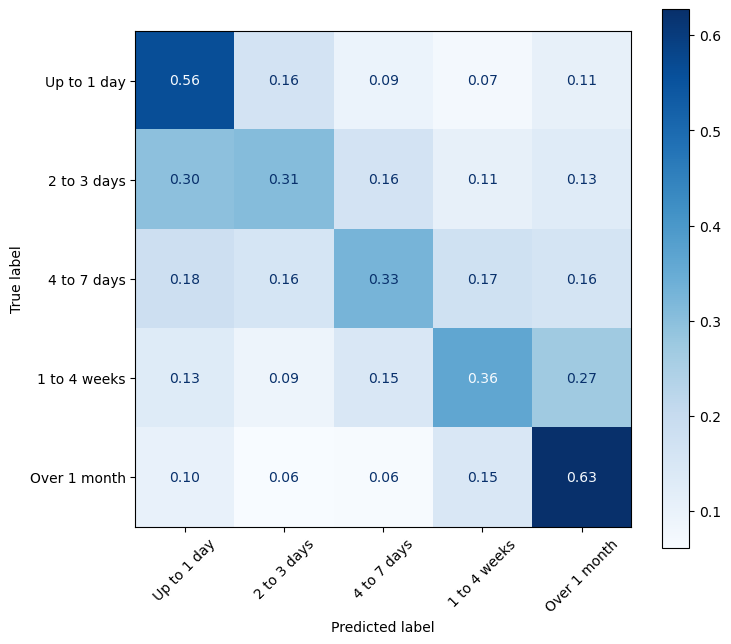

In [150]:
fig, ax = plt.subplots(figsize=(8,7))
ConfusionMatrixDisplay.from_predictions(
    y_test_class, 
    y_pred_rfc, 
    labels=labels, 
    normalize='true', 
    values_format='.2f', 
    xticks_rotation=45,
    ax=ax,
    cmap='Blues'
)